In [4]:
# source tf_env/bin/activate
# %pip install --upgrade pip

In [5]:
import tensorflow as tf

tf.__version__

'2.21.0'

In [6]:
# DOWNLOADING DATASET
mnist = tf.keras.datasets.mnist

# cargar los datos de entrenamiento y prueba
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [7]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

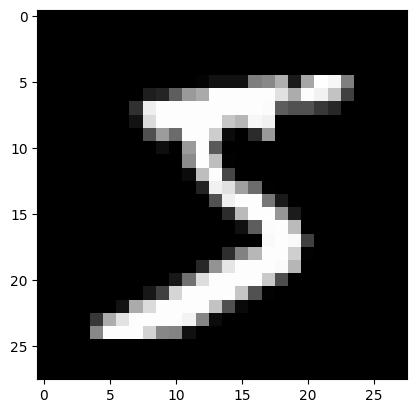

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')

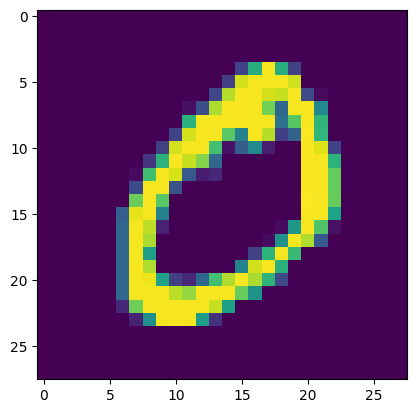

In [9]:
import matplotlib.pyplot as plt

plt.imshow(X_train[1])

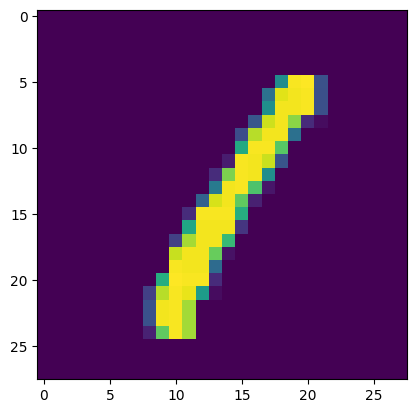

In [10]:
import matplotlib.pyplot as plt

# mostrando las imagenes de las etiquetas
plt.imshow(X_train[3])

In [11]:
# mostrando los resultados de las etiquetas
y_train[0], y_train[1], y_train[3]

(np.uint8(5), np.uint8(0), np.uint8(1))

In [12]:
import numpy as np
np.max(X_train), np.min(X_train)

(np.uint8(255), np.uint8(0))

In [13]:
# Processing the data
# normalizar los datos
X_train = X_train / 255.0

In [14]:
X_test = X_test / 255.0

In [15]:
# convierte las etiquetas a one-hot encoding
X_train = X_train.reshape(60000, 28 * 28) #784, 28*28
X_test = X_test.reshape(10000, 28 * 28) #784, 28*28

In [16]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [17]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [18]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [19]:
# secuencial -> crea una red por capa, dense ->crea capas completamente conectadas
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# se crea modelo(red neronal vacia)
mnist_model = Sequential()

# primera capa 784 para 1 neurona, SIGMOID convierte numero a un rango, SOFTMAX convierte los resultados a probabilidades
mnist_model.add(Dense(units=1, activation='sigmoid', input_shape=(784,), name='input'))
mnist_model.add(Dense(units=10, activation='softmax'))

In [20]:
# muestra la arquitectura del modelo(capas, neuronas y parametros)
mnist_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 1)              │           785 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# SGD -> es un algoritmo que ajusta los pesos (prediccion - error - ajuste de pesos -nueva prediccion)
mnist_model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy'])
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [22]:
# # # entrena el modelo, epochs -> numero de veces que se ve todo el dataset, 
# batch_size -> numero de muestras que se procesan antes de actualizar los pesos del modelo
history = mnist_model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=128, epochs=25,)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1156 - loss: 2.2699 - val_accuracy: 0.1381 - val_loss: 2.2435
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1828 - loss: 2.2223 - val_accuracy: 0.2074 - val_loss: 2.2025
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2056 - loss: 2.1863 - val_accuracy: 0.2036 - val_loss: 2.1692
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2042 - loss: 2.1553 - val_accuracy: 0.2045 - val_loss: 2.1394
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2067 - loss: 2.1272 - val_accuracy: 0.2056 - val_loss: 2.1123
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2035 - loss: 2.1013 - val_accuracy: 0.2058 - val_loss: 2.0874
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2061 - loss: 2.0776 - val_accuracy: 0.2070 - val_loss: 2.0647
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2055 - loss: 2.0559 - val_accuracy: 0.

In [23]:
# drop out- apaga las neuronas de forma aleatoria durante el entrenamiento para evitar el sobreajuste
from tensorflow.keras.layers import Dropout

In [24]:
# Reiniciar el modelo
from keras.models import Sequential
from keras.layers import Dense, Dropout

# crea un nuevo modelo con capas ocultas y dropout
mnist_model = Sequential()
# primera capa con 10 neuronas, relu convierte los numeros a un rango, input_shape es la forma de los datos de entrada
mnist_model.add(Dense(units=10, activation='relu', input_shape=(784,), name='dense_1'))
# segunda capa
mnist_model.add(Dense(units=10, activation='relu'))
# durante el entrenamiento, se apagan el 20% de las neuronas de forma aleatoria para evitar el sobreajuste
mnist_model.add(Dropout(rate=0.2))
# tercera capa
mnist_model.add(Dense(units=10, activation='relu'))
# se apagan de nuevo 
mnist_model.add(Dropout(rate=0.2))
# capa de salida
mnist_model.add(Dense(units=10, activation='softmax'))

In [25]:
# 784 entradas
#       ↓
# Dense(10, relu)
#       ↓
# Dense(10, relu)
#       ↓
# Dropout(20%)
#       ↓
# Dense(10, relu)
#       ↓
# Dropout(20%)
#       ↓
# Dense(10, softmax)

In [26]:
# compila el modelo con el optimizador Adam > SGD
mnist_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
# entrena el modelo con el nuevo optimizador y la nueva arquitectura
history = mnist_model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=128, epochs=100,)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5114 - loss: 1.4665 - val_accuracy: 0.8425 - val_loss: 0.6741
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6781 - loss: 0.9673 - val_accuracy: 0.8849 - val_loss: 0.4876
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7116 - loss: 0.8600 - val_accuracy: 0.8961 - val_loss: 0.4399
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7352 - loss: 0.8016 - val_accuracy: 0.9009 - val_loss: 0.4063
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7471 - loss: 0.7716 - val_accuracy: 0.9052 - val_loss: 0.3912
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7634 - loss: 0.7379 - val_accuracy: 0.9057 - val_loss: 0.3819
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7717 - loss: 0.7196 - val_accuracy: 0.9087 - val_loss: 0.3690
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7772 - loss: 0.7012 - val_accu

In [40]:
# Datos
#  ↓
# Normalización
#  ↓
# Flatten (aplanar los datos)
#  ↓
# Capas Dense/ReLU
#  ↓
# Dropout (opcional) (apaga neuronas de forma aleatoria para evitar el sobreajuste)
#  ↓
# Softmax (convierte salidas a probabilidades)
#  ↓
# Predicción
#  ↓
# Loss (mide que tan mal lo hizo el modelo)
#  ↓
# Optimizer (Adam o SGD) (modifica los pesos del modelo para mejorar la predicción) 
#  ↓
# Entrenamiento

In [ ]:
# guardar el historial de entrenamiento para analizarlo posteriormente
h = history.history
# ver las metricas disponibles en el historial de entrenamiento
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

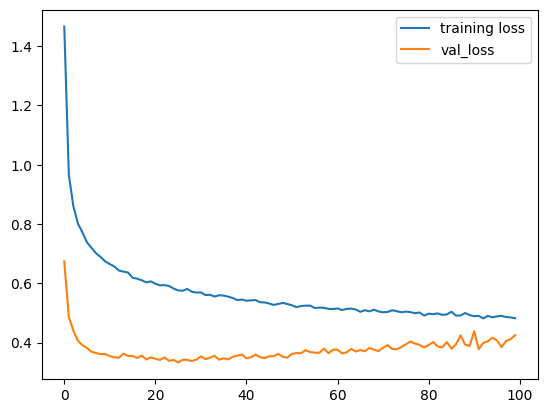

In [ ]:
# grafica de la perdida de entrenamiento y validacion
#  -> buen entrenamiento es cuando la perdida de entrenamiento y validacion disminuyen juntas, 
# si la perdida de entrenamiento disminuye pero la de validacion aumenta, es un signo de overffiting
import matplotlib.pyplot as plt
plt.plot(h['loss'], label='training loss')
plt.plot(h['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [ ]:
# evaluar el modelo con datos nuevos, calcula perdida y precision final
evaluation = mnist_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9176 - loss: 0.4256


In [ ]:
# ver configuracion del modelo
mnist_model.get_config()

{'name': 'sequential_2',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 784),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_2'},
   'registered_name': None},
  {'module': 'keras.layers',
   'class_name': 'Dense',
   'config': {'name': 'dense_1',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'units': 10,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'keras.initializers',
     'class_name': 'Zeros',
     'config': {},
     'registered_name': N

In [41]:
# from tensorflow.keras.utils import plot_model

# plot_model(
#     mnist_model,
#     to_file='modelo.png',
#     show_shapes=True,
#     show_layer_names=True
# )

In [ ]:
# ver resumen del modelo
mnist_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,542 (95.87 KB)

 Trainable params: 8,180 (31.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,362 (63.92 KB)

In [ ]:
# common neural network regresion
# # Input layer = numero de neuronas, numero de caracteristicas en el dataset
# # Hidden layer = 3 - 20 
# # Numero de neronas en hidden layer = 10 - 30
# # Funcion de activacion = RELU, sigmoid, softmax
# # Output Layer = 1 neurona sin ninguna funcion de activacion 
# # loss function = mean_squared_error

# common neural network binary classification
# # output layer = 1 neurona con funcion de activacion sigmoid
# # loss function = binary_crossentropy

# common neural network multi-class classification
# # output layer = numero de clases con funcion de activacion softmax
# # loss function = categorical_crossentropy